In [ ]:
# !pip install -U ultralytics pydicom nibabel opencv-python matplotlib numpy

  Using cached pydicom-3.0.1-py3-none-any.whl.metadata (9.4 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached ultralytics_thop-2.0.18-py3-none-any.whl.metadata (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.1 MB/s  0:00:00
Using cached pydicom-3.0.1-py3-none-any.whl (2.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 49.7 MB/s  0:00:00
Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl (46.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 75.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.9/823.9 kB 52.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 49.2 MB/s  0:00:00m0:00:0100:01
Using cached ultralytics_thop-2.0.18-py3-none-any.whl (28 kB)
  Attempting uninstall: numpy90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/8 [polars-runtime-32]
    Found existing installation: numpy 2.4.2━━━━━━━━━━━━━━━━━━ 1/8 [polars-runtime-32]
    Uninstalli

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def normalize_to_uint8(img: np.ndarray) -> np.ndarray:
    """Normalize a 2D image to uint8 [0, 255]."""
    img = img.astype(np.float32)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    img = (img * 255).clip(0, 255).astype(np.uint8)
    return img

def to_rgb(img_2d: np.ndarray) -> np.ndarray:
    """Convert grayscale 2D image to 3-channel RGB."""
    if img_2d.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {img_2d.shape}")
    return np.stack([img_2d, img_2d, img_2d], axis=-1)

def show_mask_overlay(image_rgb, mask, title=""):
    plt.figure(figsize=(6, 6))
    plt.imshow(image_rgb, cmap="gray")
    plt.imshow(mask, alpha=0.4)
    plt.title(title)
    plt.axis("off")
    plt.show()

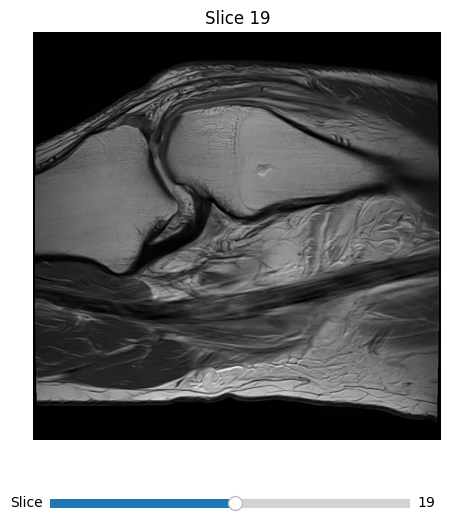

In [2]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

def normalize(img):
    img = img.astype(np.float32)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    return img

nii_path = "/Users/anshikabajpai/Desktop/AImed-lab/SEGMENTATIONS/PD-segmentations-final/AC0D3459553205_SAG_PD_TSE_6_1.nii.gz"
vol = nib.load(nii_path).get_fdata()

fig, ax = plt.subplots(figsize=(6, 6))
plt.subplots_adjust(bottom=0.2)

z0 = vol.shape[2] // 2
img_display = ax.imshow(normalize(vol[:, :, z0]), cmap="gray")
title = ax.set_title(f"Slice {z0}")
ax.axis("off")

slider_ax = plt.axes([0.2, 0.08, 0.6, 0.03])
slider = Slider(slider_ax, "Slice", 0, vol.shape[2]-1, valinit=z0, valstep=1)

def update(val):
    z = int(slider.val)
    img_display.set_data(normalize(vol[:, :, z]))
    title.set_text(f"Slice {z}")
    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()

Volume shape: (768, 768, 38)

0: 1024x1024 1 0, 1903.9ms
Speed: 24.4ms preprocess, 1903.9ms inference, 3.3ms postprocess per image at shape (1, 3, 1024, 1024)


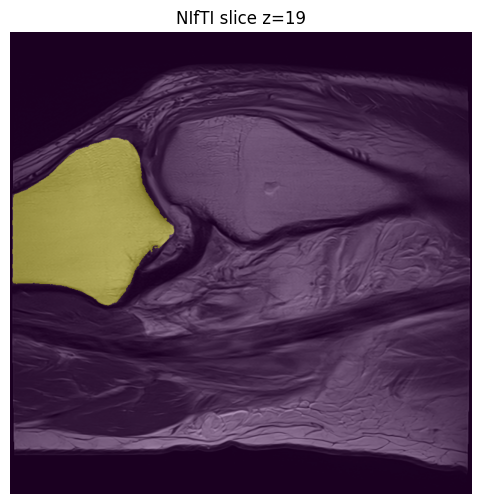

In [4]:
import nibabel as nib
from ultralytics import SAM

model = SAM("sam2_b.pt")

nii_path = "/Users/anshikabajpai/Desktop/AImed-lab/SEGMENTATIONS/PD-segmentations-final/AC0D3459553205_SAG_PD_TSE_6_1.nii.gz"
nii = nib.load(nii_path)
vol = nii.get_fdata()  # often shape: (H, W, Z) or similar

print("Volume shape:", vol.shape)

# Pick one slice along z
z = vol.shape[2] // 2
img = vol[:, :, z]

img_u8 = normalize_to_uint8(img)
img_rgb = to_rgb(img_u8)

# Example: use a positive point prompt instead of a box
# points = [[x, y]]
# labels = [1] means positive point
points = [[180, 210]]
labels = [1]

results = model(img_rgb, points=points, labels=labels)

r = results[0]
if r.masks is None:
    print("No mask predicted.")
else:
    masks = r.masks.data.cpu().numpy()
    mask = masks[0]
    show_mask_overlay(img_rgb, mask, title=f"NIfTI slice z={z}")


0: 1024x1024 1 0, 1875.2ms
Speed: 21.6ms preprocess, 1875.2ms inference, 1.0ms postprocess per image at shape (1, 3, 1024, 1024)


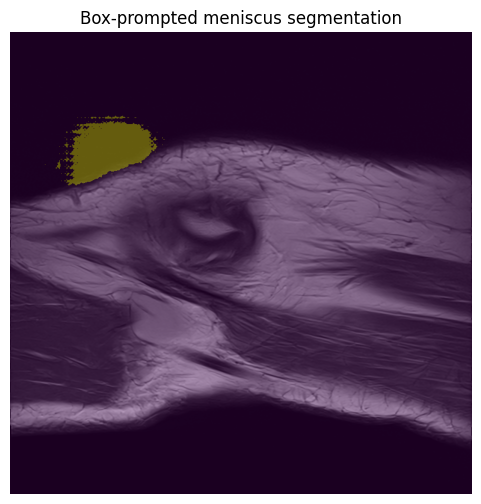

In [6]:
from ultralytics import SAM
import nibabel as nib

model = SAM("sam2_b.pt")
vol = nib.load(nii_path).get_fdata()

z = 30
img = vol[:, :, z]
img_u8 = normalize_to_uint8(img)
img_rgb = to_rgb(img_u8)

# Rough meniscus ROI
bbox = [[110, 150, 230, 250]]

results = model(img_rgb, bboxes=bbox)
r = results[0]

if r.masks is not None:
    masks = r.masks.data.cpu().numpy()
    best_mask = masks[0]
    show_mask_overlay(img_rgb, best_mask, title="Box-prompted meniscus segmentation")

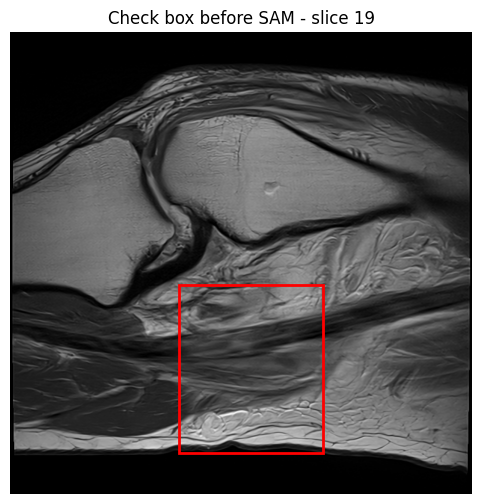


0: 1024x1024 1 0, 1854.3ms
Speed: 17.6ms preprocess, 1854.3ms inference, 1.1ms postprocess per image at shape (1, 3, 1024, 1024)


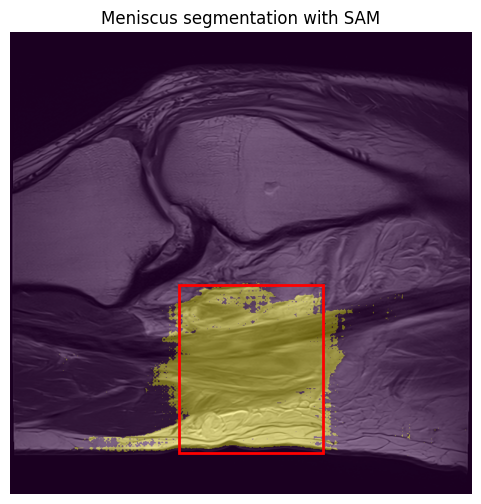

In [7]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import SAM

def normalize_to_uint8(img):
    img = img.astype(np.float32)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    return (img * 255).clip(0, 255).astype(np.uint8)

def to_rgb(img_2d):
    return np.stack([img_2d, img_2d, img_2d], axis=-1)

nii_path = "/Users/anshikabajpai/Desktop/AImed-lab/SEGMENTATIONS/PD-segmentations-final/AC0D3459553205_SAG_PD_TSE_6_1.nii.gz"
vol = nib.load(nii_path).get_fdata()

z = 19
img = vol[:, :, z]
img_u8 = normalize_to_uint8(img)
img_rgb = to_rgb(img_u8)

bbox = [280, 420, 520, 700]   # x1, y1, x2, y2
# First just visualize the box
plt.figure(figsize=(6, 6))
plt.imshow(img_u8, cmap="gray")
plt.gca().add_patch(
    plt.Rectangle((bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
                  fill=False, edgecolor="red", linewidth=2)
)
plt.title(f"Check box before SAM - slice {z}")
plt.axis("off")
plt.show()

# Then run SAM
model = SAM("sam2_b.pt")
results = model.predict(source=img_rgb, bboxes=[bbox])

r = results[0]
if r.masks is not None:
    mask = r.masks.data.cpu().numpy()[0]

    plt.figure(figsize=(6, 6))
    plt.imshow(img_u8, cmap="gray")
    plt.imshow(mask, alpha=0.4)
    plt.gca().add_patch(
        plt.Rectangle((bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
                      fill=False, edgecolor="red", linewidth=2)
    )
    plt.title("Meniscus segmentation with SAM")
    plt.axis("off")
    plt.show()
else:
    print("No mask found")

In [9]:
import nibabel as nib
import numpy as np
import imageio.v2 as imageio

def normalize_to_uint8(img):
    img = img.astype(np.float32)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    return (img * 255).clip(0, 255).astype(np.uint8)

nii_path = "/Users/anshikabajpai/Desktop/AImed-lab/SEGMENTATIONS/PD-segmentations-final/AC0D3459553205_SAG_PD_TSE_6_1.nii.gz"
vol = nib.load(nii_path).get_fdata()

z = 19
img = vol[:, :, z]
img_u8 = normalize_to_uint8(img)

# MedSAM examples are image-based, so save the selected slice
imageio.imwrite("slice19.png", img_u8)
print("saved slice19.png")

saved slice19.png


In [10]:
!python MedSAM_Inference.py \
  -i "slice19.png" \
  -o outputs/ \
  --box "[280, 420, 520, 700]" \
  -chk "/Users/anshikabajpai/Desktop/AImed-lab/localization_meniscus/MedSAM/medsam_vit_b.pth" \
  --device cpu

/opt/homebrew/Cellar/python@3.11/3.11.12/Frameworks/Python.framework/Versions/3.11/Resources/Python.app/Contents/MacOS/Python: can't open file '/Users/anshikabajpai/Desktop/github/MedSam_segmentation/pretrained_model_no_finetuning/MedSAM_Inference.py': [Errno 2] No such file or directory


In [11]:
!find . -name "*.pth"

In [ ]:
# !wget -O medsam_vit_b.pth https://zenodo.org/records/10689643/files/medsam_vit_b.pth

--2026-04-20 20:15:26--  https://zenodo.org/records/10689643/files/medsam_vit_b.pth
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 188.185.48.75, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375049145 (358M) [application/octet-stream]
Saving to: ‘medsam_vit_b.pth’

medsam_vit_b.pth    100%[===================>] 357.67M  21.5MB/s    in 18s     

2026-04-20 20:15:45 (19.4 MB/s) - ‘medsam_vit_b.pth’ saved [375049145/375049145]

